In [50]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_unified as eu
import EI.ei_jax_2 as ej
import EI.ei_phonon as pb
from EI.ei_utils import gap_info
from fixed_baths import k_path, take_path, color_line, solve_state, plot_dispersion

from utils.logger import logger, tqdm_bar
from utils.plotting_utils import Plotter, plot_cmap, format_ax, add_legend, plot_cmap, plot_phase_diag, color_map


import importlib
pb = importlib.reload(pb)
ej = importlib.reload(ej)
jax.clear_caches()

In [51]:
from utils.cosmetics import apply_plt_style, SET1_LIST
apply_plt_style()

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/"
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [52]:
cfg_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_test.yaml")
cfg_ph_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_phonons.yaml")

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)
with cfg_ph_path.open("r") as f:
    cfg_ph = yaml.safe_load(f)

md = cfg_ph["model"]
eq = cfg_ph["equilibrium"]
sc = cfg_ph["scan"]
op = cfg_ph["open_system"]
op_prod = cfg["open_system"]

nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)

p = eu.MFPars(**md["mean_field"])

In [53]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
m0 = s0.m
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd_ref, p, **eq["critical"])

logger.info(f"Delta_0 = {d0}")
logger.info(f"m_0     = {m0}")
logger.info(f"mu0     = {mu0}")
logger.info(f"T_c     = {tc}")

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[07:58:32] [INFO    ] Delta_0 = 1.0000516844764111
[07:58:32] [INFO    ] m_0     = -0.6843383434372652
[07:58:32] [INFO    ] mu0     = 3.2003407445809757
[07:58:32] [INFO    ] T_c     = 0.5352354225531222


In [54]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

In [55]:
st = ej.mf_state(bd_ref, p, s0.d, s0.m)
t1n, t2n = 6.5, 0.2
t1, t2 = t1n * tc, t2n * tc

Phonon kernel table:   0%|          | 0/64 [00:00<?, ?it/s]

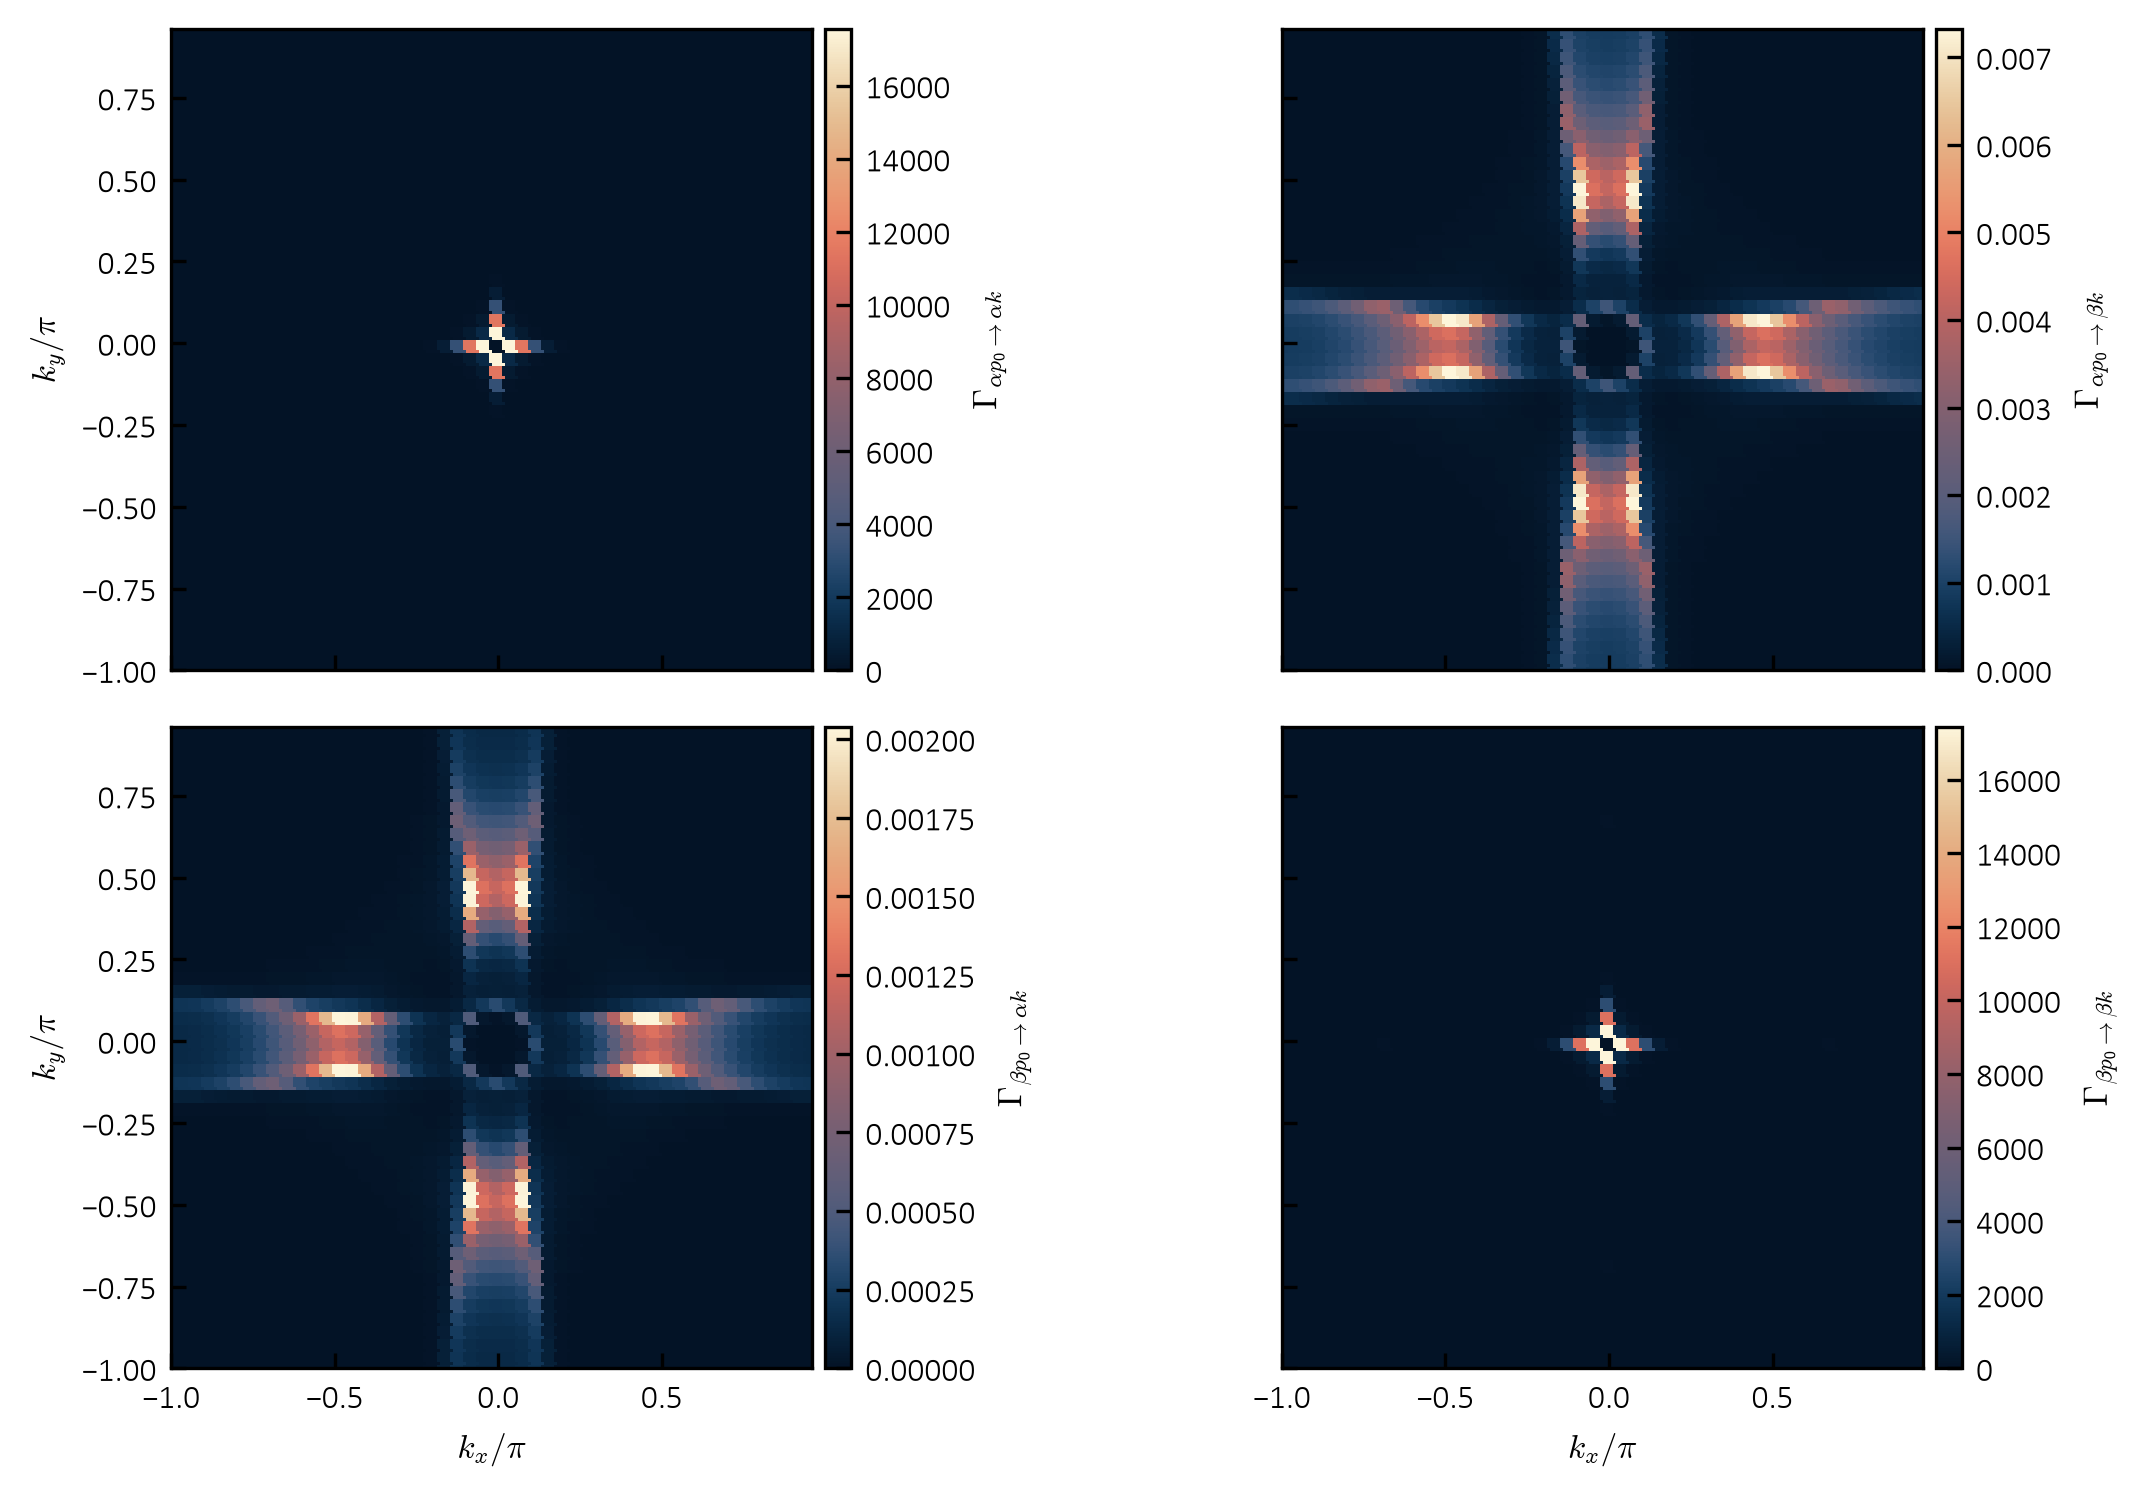

In [56]:
bc = cfg_ph["open_system"]["bath"]
pa = dict(bc["pars"])
fn = getattr(pb, bc["rate"])
bs = (fn(t1, bd_ref.k, name="bath_1", **pa),
      fn(t2, bd_ref.k, name="bath_2", **pa))

nk = md["nk"]["reference"]
ip = (int(2* nk // 4), nk // 2)
p0 = np.ravel_multi_index(ip, bd_ref.shape)

r_all = []
for mu in [0, 1]:
    r = np.asarray(pb.source_rates(st, bs, mu, p0))
    r = r.reshape((2,) + bd_ref.shape)
    r_all.append(r)

r_matrix = np.array(r_all)  # Shape: (2, 2, nk_x, nk_y)

# 2. Extract k-space grid
k = bd_ref.k.reshape(bd_ref.shape + (2,))
kx = k[:, 0, 0] / np.pi
ky = k[0, :, 1] / np.pi

# 3. Plotting in a 2x2 grid with independent scales & colorbars
lb = (r"\alpha", r"\beta")
pt = Plotter()

with pt.figure(name="source_rates_2x2_indep", shape=(2, 2), h=1.4, w=2.2, sharex=True, sharey=True) as plt1:
    for mu in range(2):       # Rows: Source branch
        for nu in range(2):   # Columns: Target branch
            ax = plt1.ax[mu, nu]
            rate_data = r_matrix[mu, nu].T
            
            # Independent scaling for this panel
            vmax_panel = max(float(rate_data.max()), np.finfo(float).eps)
            norm_panel = Normalize(vmin=0.0, vmax=vmax_panel)
            
            # Draw heatmap using project helper
            im = color_map(ax, kx, ky, rate_data, norm=norm_panel)
            
            # Panel-specific colorbar placed inside each axis layout
            plt1.colorbar(
                im, 
                label=rf"$\Gamma_{{{lb[mu]} p_0 \to {lb[nu]} k}}$", 
                ax=ax, 
                external=True, 
                width="4%"
            )
            
            # Axis styling
            format_ax(ax, x=kx, grid=False)
            ax.set_ylim(ky[0], ky[-1])
            ax.set_aspect("equal")
            
            # Edge-only labels to prevent clutter
            if nu == 0:
                ax.set_ylabel(r"$k_y/\pi$")
            if mu == 1:
                ax.set_xlabel(r"$k_x/\pi$")

In [57]:
# bc_prod = op_prod["bath"]
# pa_prod = {
#     **bc_prod["pars"],
#     "rate": getattr(ej, bc_prod["rate"]),
# }

# # The chemical potential comes from pa_prod; mu is the source branch.
# bs_prod = (
#     ej.gam_db(t=t1, name="product_1", **pa_prod),
#     ej.gam_db(t=t2, name="product_2", **pa_prod),
# )

# # R[destination, source], summed over both baths.
# # These are Gamma rates, before multiplication by n_source*(1-n_destination).
# n_k = int(np.prod(bd_ref.shape))
# source = int(mu * n_k + p0)

# r_prod = np.asarray(ej.dense_rates(st, bs_prod)[:, source])
# r_prod = r_prod.reshape((2,) + bd_ref.shape)

# for nu in range(2):
#     plot_cmap(
#         kx, ky, r_prod[nu].T,
#         rf"$\Gamma^{{\mathrm{{prod}}}}_{{{lb[mu]} p_0 \to {lb[nu]} k}}$",
#         norm=Normalize(
#             vmin=0.0,
#             vmax=max(float(r_prod[nu].max()), np.finfo(float).eps),
#         ),
#         pt=pt,
#         xlabel=r"$k_x/\pi$",
#         ylabel=r"$k_y/\pi$",
#     )

Source momenta:   0%|          | 0/2500 [00:00<?, ?it/s]

Rate maps:   0%|          | 0/2 [00:00<?, ?it/s]

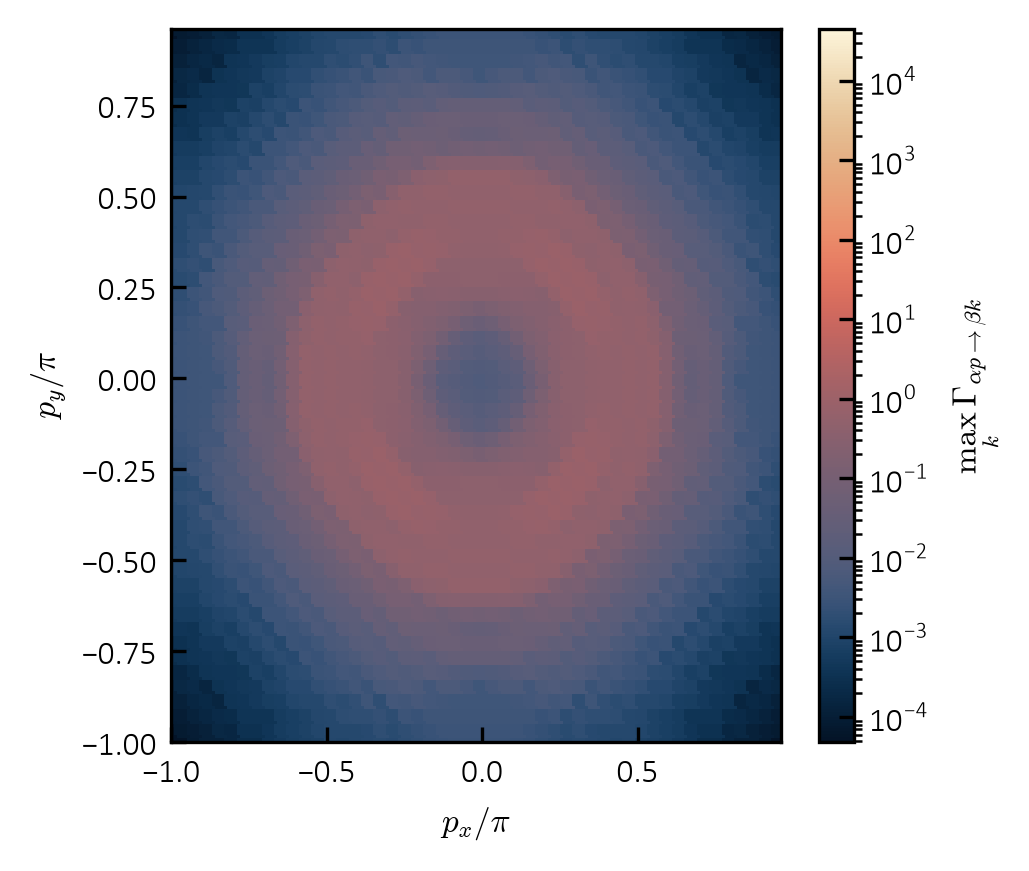

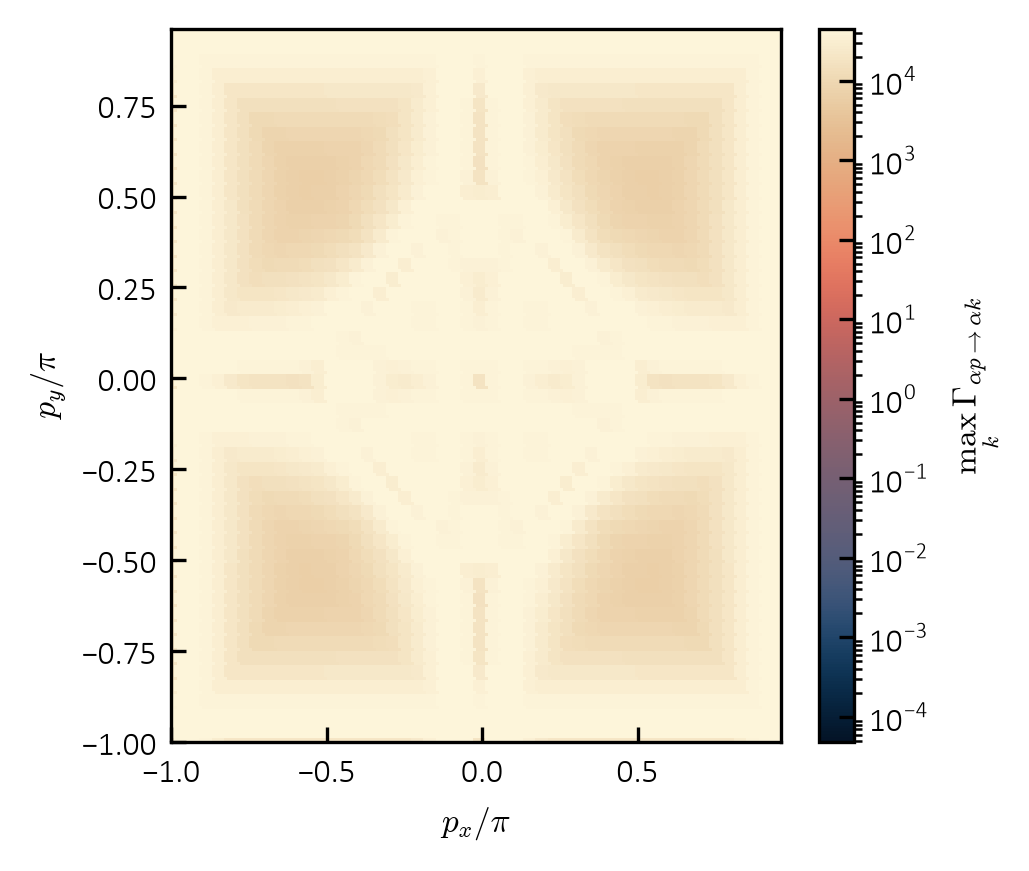

In [58]:
mu = 0
nk = int(np.prod(bd_ref.shape))
rm = np.empty((2, nk))

for j in tqdm(range(nk), desc="Source momenta"):
    rr = jnp.asarray(pb.source_rates(st, bs, mu, j)).reshape(2, nk)
    rr = rr.at[mu, j].set(0.0)  # Exclude scattering into the same state.
    rm[:, j] = np.asarray(jnp.max(rr, axis=1))

# Shared logarithmic scale.
z = rm[rm > 0.0]
if z.size:
    lo, hi = float(z.min()), float(z.max())
    norm = LogNorm(vmin=lo, vmax=hi if hi > lo else 2.0 * lo)
else:
    norm = Normalize(vmin=0.0, vmax=1.0)

cm0 = cmaps.lipari.copy()
cm0.set_bad("0.85")
rm = np.where(rm > 0.0, rm, np.nan).reshape((2,) + bd_ref.shape)

kp = np.asarray(bd_ref.k).reshape(bd_ref.shape + (2,))
px, py = kp[:, 0, 0] / np.pi, kp[0, :, 1] / np.pi
lb = (r"\alpha", r"\beta")

for nu in tqdm((1, 0), desc="Rate maps"):
    plot_cmap(
        px, py, rm[nu].T,
        rf"$\max_k \Gamma_{{\alpha p \to {lb[nu]} k}}$",
        cmap=cm0, norm=norm, pt=pt,
        xlabel=r"$p_x/\pi$", ylabel=r"$p_y/\pi$",
    )

In [59]:
# op = cfg_ph["open_system"]
# eq = cfg_ph["equilibrium"]

# bc = op["bath"]
# fn = getattr(pb, bc["rate"])
# pa = dict(bc["pars"])

# nt = len(tn)

# da = np.full((nt, nt), np.nan)
# ma = np.full((nt, nt), np.nan)
# er = np.full((nt, nt), np.nan)
# it = np.zeros((nt, nt), dtype=int)
# ok = np.zeros((nt, nt), dtype=bool)

# gh = np.full((nt, nt), np.nan)
# gg = np.full((nt, nt), np.nan)
# gd = np.full((nt, nt), np.nan)
# gi = np.full((nt, nt), np.nan)

# de = s0.d
# me = s0.m
# ds = 0.2 * max(d0, 1.0)

# for j in tqdm(range(nt), desc="T2"):
#     t2 = float(t2a[j])

#     se = eu.solve_eq(
#         bd, p, t=t2,
#         d=max(abs(de), 1.0e-8),
#         m=me,
#         mix=(0.15, 0.15),
#         tol=1.0e-9,
#         nmax=20000,
#         chk=20,
#         prog=False,
#     )

#     n = se.n.copy()
#     d = float(se.d)
#     m = float(se.m)

#     b2 = fn(
#         t2, bd.k,
#         name="bath_2",
#         **pa,
#     )

#     for i in tqdm(
#         range(j, nt),
#         desc="T1",
#         leave=False,
#     ):
#         t1 = float(t1a[i])

#         bs = (
#             fn(
#                 t1, bd.k,
#                 name="bath_1",
#                 **pa,
#             ),
#             b2,
#         )

#         so = ej.solve_open(
#             bd, p, n, bs,
#             d=d, m=m,
#             **op["solve"],
#         )

#         da[j, i] = abs(so.d)
#         ma[j, i] = so.m
#         er[j, i] = so.err
#         it[j, i] = so.it
#         ok[j, i] = so.ok

#         gp = gap_info(bd, so.st)

#         gh[j, i] = gp["hartree_g"]
#         gg[j, i] = gp["diag_g"]
#         gd[j, i] = gp["diag_min"]
#         gi[j, i] = gp["diag_ind"]

#         n = so.n.copy()
#         d = max(abs(so.d), ds)
#         m = float(so.m)

#         da[i, j] = da[j, i]
#         ma[i, j] = ma[j, i]
#         er[i, j] = er[j, i]
#         it[i, j] = it[j, i]
#         ok[i, j] = ok[j, i]

#         gh[i, j] = gh[j, i]
#         gg[i, j] = gg[j, i]
#         gd[i, j] = gd[j, i]
#         gi[i, j] = gi[j, i]

#     de = float(se.d)
#     me = float(se.m)

# print(f"Converged: {ok.sum()} / {ok.size}")

# plot_phase_diag(
#     da,
#     d0,
#     tn,
# )

In [60]:
# plot_phase_diag(
#     np.where(ok, da, np.nan),
#     d0,
#     tn,
# )

In [61]:
def plot_disp_ph(pt, bd, st, ec, bs):
    ij, x, xt = k_path(bd)
    eb = take_path(np.stack((bd.ea, bd.eb)), ij, bd.shape)
    eh = take_path(np.stack((st.st.eah, st.st.ebh)), ij, bd.shape) - ec
    ed = take_path(st.st.e, ij, bd.shape) - ec
    nq = take_path(st.n, ij, bd.shape)
    u = take_path(st.st.u, ij, bd.shape)
    v = take_path(st.st.v, ij, bd.shape)

    qp = take_path(np.linalg.norm(bd.k, axis=1), ij, bd.shape)
    ps = tuple(dict.fromkeys((b.cs, b.qd) for b in bs))
    norm = Normalize(0.0, 1.0)
    sm = ScalarMappable(norm=norm, cmap=cmaps.vanimo)

    with pt.figure(h=1.0) as q:
        a = q.ax
        a.plot(x, eb[0], color=SET1_LIST[0], ls="--", lw=0.9,
               label=r"$\varepsilon_{a\mathbf{k}}$")
        a.plot(x, eb[1], color=SET1_LIST[1], ls="--", lw=0.9,
               label=r"$\varepsilon_{b\mathbf{k}}$")
        a.plot(x, eh[0], color=SET1_LIST[0], lw=1.1,
               label=r"$\varepsilon^{\mathrm{H}}_{a\mathbf{k}}-E_c$")
        a.plot(x, eh[1], color=SET1_LIST[1], lw=1.1,
               label=r"$\varepsilon^{\mathrm{H}}_{b\mathbf{k}}-E_c$")

        color_line(a, x, ed[0], nq[0], u**2, cmaps.vanimo, norm,
                   label=r"$E_{\alpha\mathbf{k}}-E_c$")
        color_line(a, x, ed[1], nq[1], v**2, cmaps.vanimo, norm, ls="--",
                   label=r"$E_{\beta\mathbf{k}}-E_c$")

        wp = []
        for j, (cs, qd) in enumerate(tqdm(ps, desc="Phonon branches", leave=False)):
            om = np.where(qp <= qd * (1 + 1.e-12), cs * qp, np.nan)
            wp.append(om)
            lb = (r"$\omega_{\mathbf{q}}$" if len(ps) == 1
                  else rf"$\omega_{{\mathbf{{q}},{j + 1}}}$")
            a.plot(x, om, color=SET1_LIST[(4 + j) % len(SET1_LIST)],
                   ls="-.", lw=1.4, label=lb)

        a.axvline(xt[1], color="0.75", lw=0.7)
        a.axvline(xt[2], color="0.75", lw=0.7)
        a.axhline(0.0, color="0.7", ls=":", lw=0.6)

        yy = np.r_[eb.ravel(), eh.ravel(), ed.ravel(), np.asarray(wp).ravel()]
        yy = yy[np.isfinite(yy)]
        dy = 0.04 * max(np.ptp(yy), 1.0)

        format_ax(
            a, x=x, xlabel=r"$\mathbf{k},\,\mathbf{q}$",
            ylabel=r"$E,\ \omega_{\mathbf{q}}$",
            ylim=(yy.min() - dy, yy.max() + dy),
            xticks=xt,
            xticklabels=[r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"],
        )
        add_legend(a, top=True, ncol=3, fontsize=7)
        q.colorbar(sm, r"$n_{\lambda\mathbf{k}}$", ax=a)
        q.layout((0, 0, 1, 0.83))

    return q.fig, q.ax

In [62]:
se = eu.solve_eq(
    bd, p, t=0.75*tc, d=d0, m=s0.m,
    **{**eq["solve"], "prog": False},
)

print(se.d, se.m)

0.7845989036204528 -0.7052627875791126


In [ ]:
r1, r2 = 0.75, 0.75
t1, t2 = r1 * tc, r2 * tc
eta_a = np.array([1.])

bc = op["bath"]
fn = getattr(pb, bc["rate"])
pa = dict(bc["pars"])

se = eu.solve_eq(
    bd, p, t=t2, d=d0, m=s0.m,
    **{**eq["solve"], "prog": False},
)

#random pogoji
ni = np.ones_like(se.n.copy())*0.5
di = 0.8
mi = -0.6

# ni = se.n.copy()
# di = se.d
# mi = se.m

ns = int(op["solve"]["chk"]) 
nstep = int(op["solve"]["nmax"])
nc = (nstep + ns - 1) // ns

w = np.asarray(bd.w, dtype=float)
out = []

for eta in tqdm(eta_a, desc="Energy widths"):
    bp = {**pa, "eta": 1.0}
    bs = (
        fn(t1, bd.k, name="bath_1", **bp),
        fn(t2, bd.k, name="bath_2", **bp),
    )

    n = ni.copy()
    d, m = di, mi
    tt = 0.0

    z = {
        "t": [], "d": [], "m": [], "na": [],
        "gn": [], "gs": [], "err": [], "cur": [],
    }

    for j in tqdm(
        range(nc + 1),
        desc=rf"$\eta={eta:g}$",
        leave=False,
    ):
        if j:
            nq = min(ns, nstep - (j - 1) * ns)

            so = ej.solve_open(
                bd, p, n, bs, d=d, m=m,
                **{
                    **op["solve"],
                    "nmax": ns,
                    "chk": ns,
                    "prog": False,
                    "tol": 1e-10
                },
            )

            n = so.n.copy()
            d = float(so.d)
            m = float(so.m)
            tt += float(so.hist["t"][-1])

        st = ej.mf_state(bd, p, d=d, m=m)
        tg = ej.targets(bd, p, st, n)

        gn = (
            float(tg.d) / d
            if abs(d) > np.finfo(float).eps else np.nan
        )

        z["t"].append(tt)
        z["d"].append(d)
        z["m"].append(m)
        z["na"].append(float(np.sum(w * n[0])))
        z["gn"].append(gn)
        z["err"].append(float(so.err) if j else np.nan)
        z["cur"].append(
            float(so.hist["cur"][-1]) if j else np.nan
        )

    out.append({k: np.asarray(v) for k, v in z.items()})

Energy widths:   0%|          | 0/1 [00:00<?, ?it/s]

$\eta=1$:   0%|          | 0/101 [00:00<?, ?it/s]

Phonon kernel table:   0%|          | 0/64 [00:00<?, ?it/s]

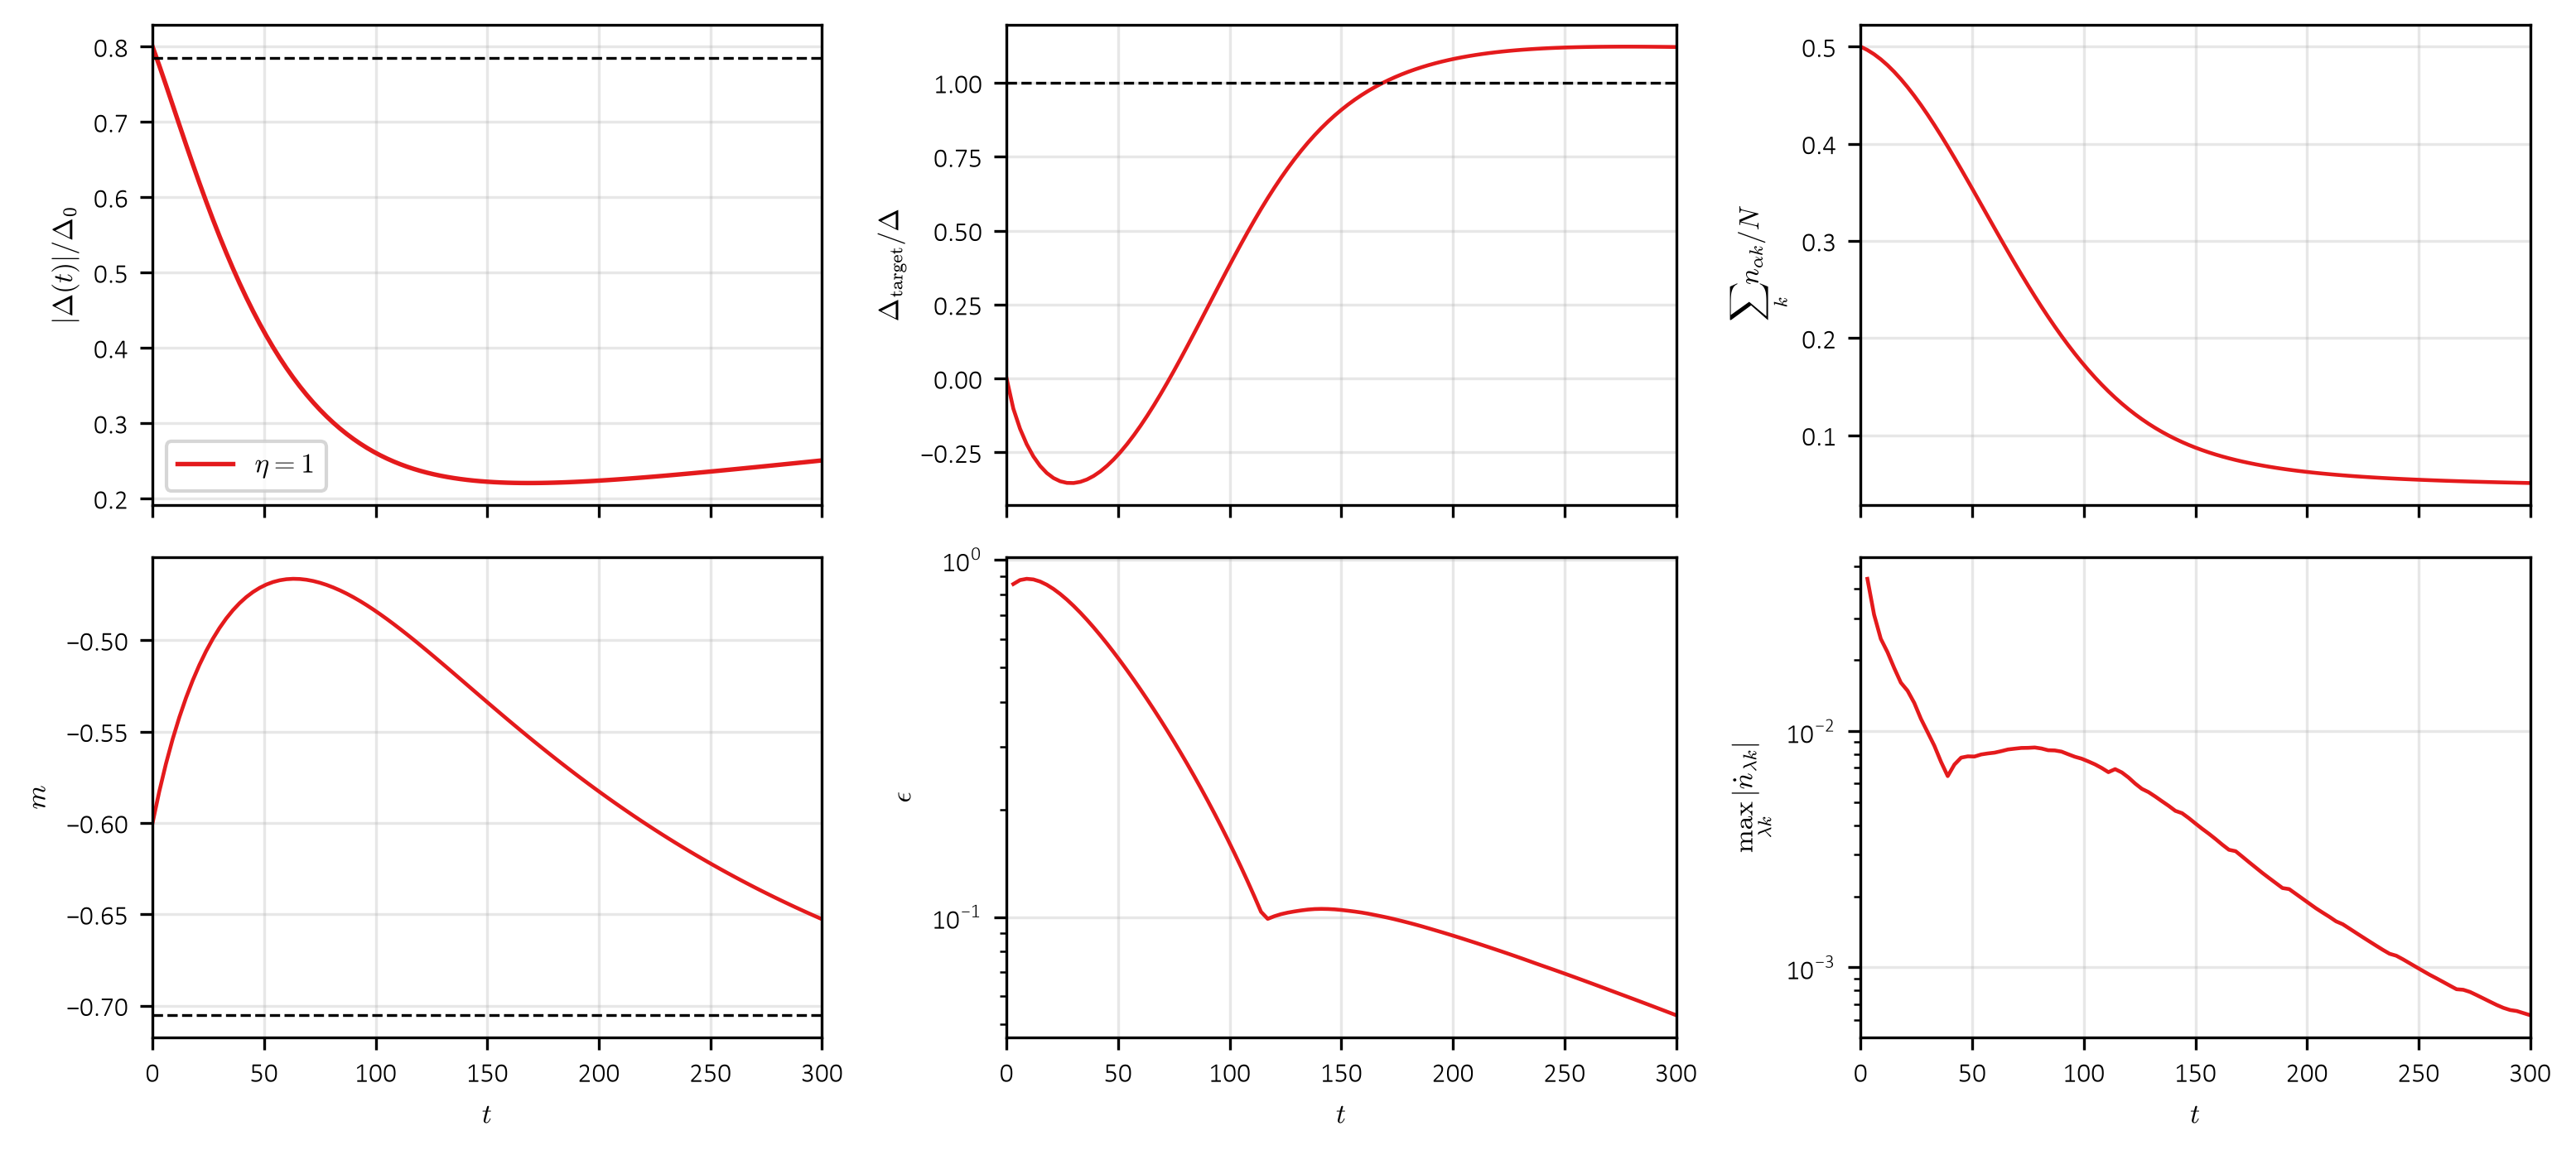

In [64]:
h = 1.35
fig, ax = plt.subplots(
    2, 3, sharex=True,
    figsize=(3 * 3.47412, h * 3.47412),
)

for i in range(len(out)):
    z = out[i]
    c = SET1_LIST[i]
    lb = rf"$\eta={eta_a[i]:g}$"

    ax[0, 0].plot(
        z["t"], np.abs(z["d"]) / d0,
        color=c, linewidth=1.3, label=lb,
    )
    ax[0, 1].plot(
        z["t"], z["gn"],
        color=c, linewidth=1.1,
    )
    ax[0, 2].plot(
        z["t"], z["na"],
        color=c, linewidth=1.1,
    )
    ax[1, 0].plot(
        z["t"], z["m"],
        color=c, linewidth=1.1,
    )
    ax[1, 1].semilogy(
        z["t"][1:], z["err"][1:],
        color=c, linewidth=1.1,
    )
    ax[1, 2].semilogy(
        z["t"][1:], z["cur"][1:],
        color=c, linewidth=1.1,
    )

ax[0, 1].axhline(
    1.0, color="black",
    linestyle="--", linewidth=0.8,
)

ax[0, 0].axhline(
    se.d, color="black",
    linestyle="--", linewidth=0.8,
)

ax[1, 0].axhline(
    se.m, color="black",
    linestyle="--", linewidth=0.8,
)

ax[0, 0].set_ylabel(r"$|\Delta(t)|/\Delta_0$")
ax[0, 1].set_ylabel(r"$\Delta_{\mathrm{target}}/\Delta$")
ax[0, 2].set_ylabel(r"$\sum_k n_{\alpha k}/N$")
ax[1, 0].set_ylabel(r"$m$")
ax[1, 1].set_ylabel(r"$\epsilon$")
ax[1, 2].set_ylabel(
    r"$\max_{\lambda k}|\dot n_{\lambda k}|$"
)

xr = max(z["t"][-1] for z in out)

for a in ax.ravel():
    a.set_xlim(0.0, xr)
    a.grid(alpha=0.3)

for a in ax[1]:
    a.set_xlabel(r"$t$")

ax[0, 0].legend()

plt.tight_layout()
plt.show()

In [ ]:
r1, r2 = 0.9, 0.9
t1, t2 = r1 * tc, r2 * tc
eta_a = np.array([1.0])

bc = op["bath"]
fn = getattr(pb, bc["rate"])
pa = dict(bc["pars"])

se = eu.solve_eq(
    bd, p, t=t2, d=d0, m=s0.m,
    **{**eq["solve"], "prog": False},
)

ni = np.ones_like(se.n.copy())*0.5
di = 0.8
mi = -0.6

ns = int(op["solve"]["chk"]) 
nstep = int(op["solve"]["nmax"]) 
nc = (nstep + ns - 1) // ns

mix = (0.05, 0.05, 0.02)
tol = 1.0e-10

w = np.asarray(bd.w, dtype=float)
out = {"open": [], "fixed": []}
fin = {"open": [], "fixed": []}

for eta in tqdm(eta_a, desc="Energy widths"):
    bp = {**pa, "eta": float(eta)}
    bs = (
        fn(t1, bd.k, name="bath_1", **bp),
        fn(t2, bd.k, name="bath_2", **bp),
    )

    for md in ("open", "fixed"):
        n = ni.copy()
        d, m = float(di), float(mi)
        ii = 0

        z = {
            "it": [], "d": [], "m": [], "na": [],
            "gn": [], "err": [], "cur": [],
        }

        for j in tqdm(
            range(nc + 1),
            desc=rf"{md}, $\eta={eta:g}$",
            leave=False,
        ):
            if j:
                nq = min(ns, nstep - (j - 1) * ns)

                if md == "open":
                    so = ej.solve_open(
                        bd, p, n, bs, d=d, m=m,
                        **{
                            **op["solve"],
                            "nmax": nq,
                            "chk": 10,
                            "prog": False,
                            "tol": tol,
                        },
                    )
                else:
                    so = ej.solve_fixed(
                        bd, p, n, bs, d=d, m=m,
                        mix=mix,
                        tol=tol,
                        nmax=nq,
                        chk=nq,
                        prog=False,
                    )

                n = so.n.copy()
                d = float(so.d)
                m = float(so.m)
                ii += int(so.it)

            st = ej.mf_state(bd, p, d=d, m=m)
            tg = ej.targets(bd, p, st, n)

            gn = (
                float(tg.d) / d
                if abs(d) > np.finfo(float).eps
                else np.nan
            )

            z["it"].append(ii)
            z["d"].append(d)
            z["m"].append(m)
            z["na"].append(float(np.sum(w * n[0])))
            z["gn"].append(gn)
            z["err"].append(
                float(so.err) if j else np.nan
            )
            z["cur"].append(
                float(so.hist["cur"][-1]) if j else np.nan
            )

        out[md].append({
            q: np.asarray(v) for q, v in z.items()
        })
        fin[md].append({
            "n": n.copy(),
            "d": d,
            "m": m,
            "err": float(z["err"][-1]),
        })

Energy widths:   0%|          | 0/1 [00:00<?, ?it/s]

open, $\eta=1$:   0%|          | 0/101 [00:00<?, ?it/s]

fixed, $\eta=1$:   0%|          | 0/101 [00:00<?, ?it/s]

Comparison curves:   0%|          | 0/1 [00:00<?, ?it/s]

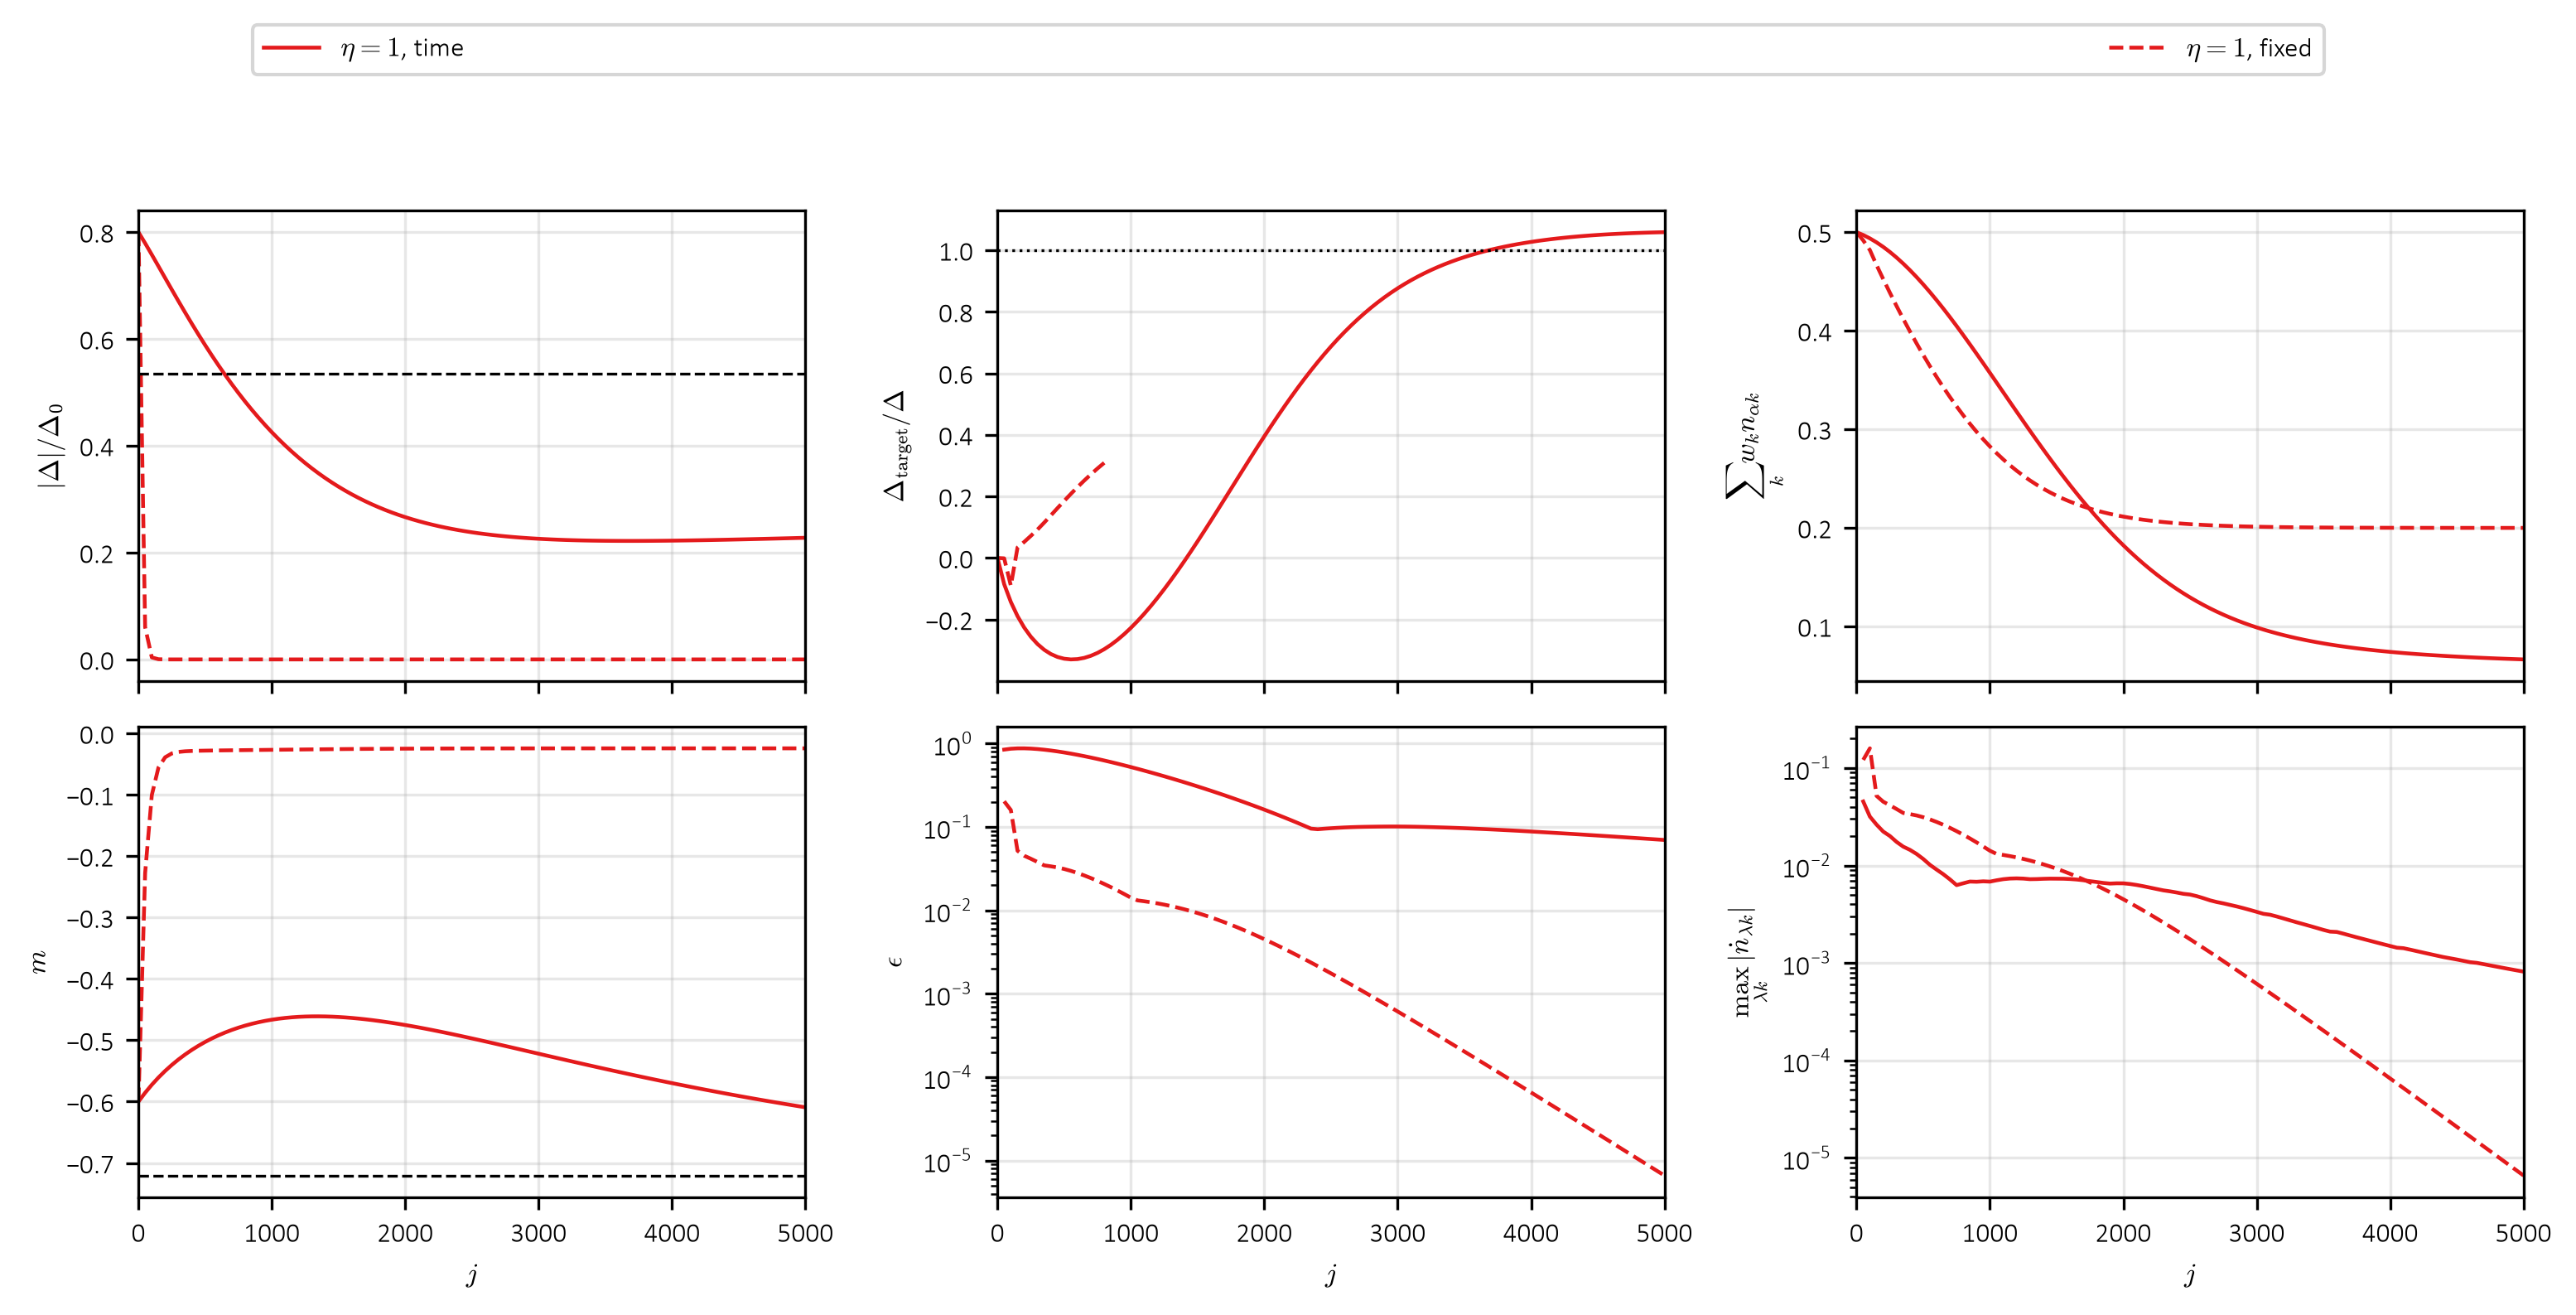

In [ ]:
h = 1.45
fig, ax = plt.subplots(
    2, 3, sharex=True,
    figsize=(3 * 3.47412, h * 3.47412),
)

for i, eta in enumerate(tqdm(eta_a, desc="Comparison curves")):
    c = SET1_LIST[i]

    for md, ls, nm in (
        ("open", "-", "time"),
        ("fixed", "--", "fixed"),
    ):
        z = out[md][i]
        lb = rf"$\eta={eta:g}$, {nm}"

        ax[0, 0].plot(
            z["it"], np.abs(z["d"]) / d0,
            color=c, linestyle=ls, linewidth=1.1, label=lb,
        )
        ax[0, 1].plot(
            z["it"], z["gn"],
            color=c, linestyle=ls, linewidth=1.1,
        )
        ax[0, 2].plot(
            z["it"], z["na"],
            color=c, linestyle=ls, linewidth=1.1,
        )
        ax[1, 0].plot(
            z["it"], z["m"],
            color=c, linestyle=ls, linewidth=1.1,
        )
        ax[1, 1].semilogy(
            z["it"][1:], z["err"][1:],
            color=c, linestyle=ls, linewidth=1.1,
        )
        ax[1, 2].semilogy(
            z["it"][1:], z["cur"][1:],
            color=c, linestyle=ls, linewidth=1.1,
        )

ax[0, 1].axhline(
    1.0, color="black",
    linestyle=":", linewidth=0.8,
)

ax[0, 0].axhline(
    se.d, color="black",
    linestyle="--", linewidth=0.8,
)

ax[1, 0].axhline(
    se.m, color="black",
    linestyle="--", linewidth=0.8,
)
ax[0, 0].set_ylabel(r"$|\Delta|/\Delta_0$")
ax[0, 1].set_ylabel(r"$\Delta_{\mathrm{target}}/\Delta$")
ax[0, 2].set_ylabel(r"$\sum_k w_k n_{\alpha k}$")
ax[1, 0].set_ylabel(r"$m$")
ax[1, 1].set_ylabel(r"$\epsilon$")
ax[1, 2].set_ylabel(r"$\max_{\lambda k}|\dot n_{\lambda k}|$")

xl = min(z["it"][0] for q in out.values() for z in q)
xr = max(z["it"][-1] for q in out.values() for z in q)

for a in ax.ravel():
    a.set_xlim(xl, xr)
    a.grid(alpha=0.3)

for a in ax[1]:
    a.set_xlabel(r"$j$")

hd, lb = ax[0, 0].get_legend_handles_labels()
fig.legend(
    hd, lb,
    bbox_to_anchor=(0.1, 0.995, 0.8, 0.1),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=3,
)

plt.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

In [53]:
tn = np.asarray(tn, dtype=float)
t1a = tn * tc
t2a = tn * tc
nt = tn.size

bc = op["bath"]
fn = getattr(pb, bc["rate"])
pa = dict(bc["pars"])

fp = {
    "mix": (0.2, 0.1, 0.1),
    "tol": 1.0e-10,
    "nmax": 20000,
    "chk": 100,
    "prog": False,
}

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = float(s0.d)
me = float(s0.m)
ds = 1.0e-3 * max(abs(d0), 1.0)

for j in tqdm(range(nt), desc="T2"):
    t2 = float(t2a[j])

    se = eu.solve_eq(
        bd, p, t=t2,
        d=max(abs(de), 1.0e-8),
        m=me,
        **{**eq["solve"], "prog": False},
    )

    n = se.n.copy()
    d = float(se.d)
    m = float(se.m)

    for i in tqdm(
        range(j, nt),
        desc="T1",
        leave=False,
    ):
        t1 = float(t1a[i])

        bs = (
            fn(t1, bd.k, name="bath_1", **pa),
            fn(t2, bd.k, name="bath_2", **pa),
        )

        so = ej.solve_fixed(
            bd, p, n, bs,
            d=d,
            m=m,
            **fp,
        )

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

        n = so.n.copy()
        d = max(abs(float(so.d)), ds)
        m = float(so.m)

    de = float(se.d)
    me = float(se.m)

print(f"Converged: {np.count_nonzero(ok)} / {ok.size}")
print(f"Nonconverged: {np.count_nonzero(~ok)}")
print(f"Maximum residual: {np.nanmax(er):.3e}")

T2:   0%|          | 0/15 [00:00<?, ?it/s]

T1:   0%|          | 0/15 [00:00<?, ?it/s]

Phonon kernel table:   0%|          | 0/64 [00:00<?, ?it/s]

KeyboardInterrupt: 

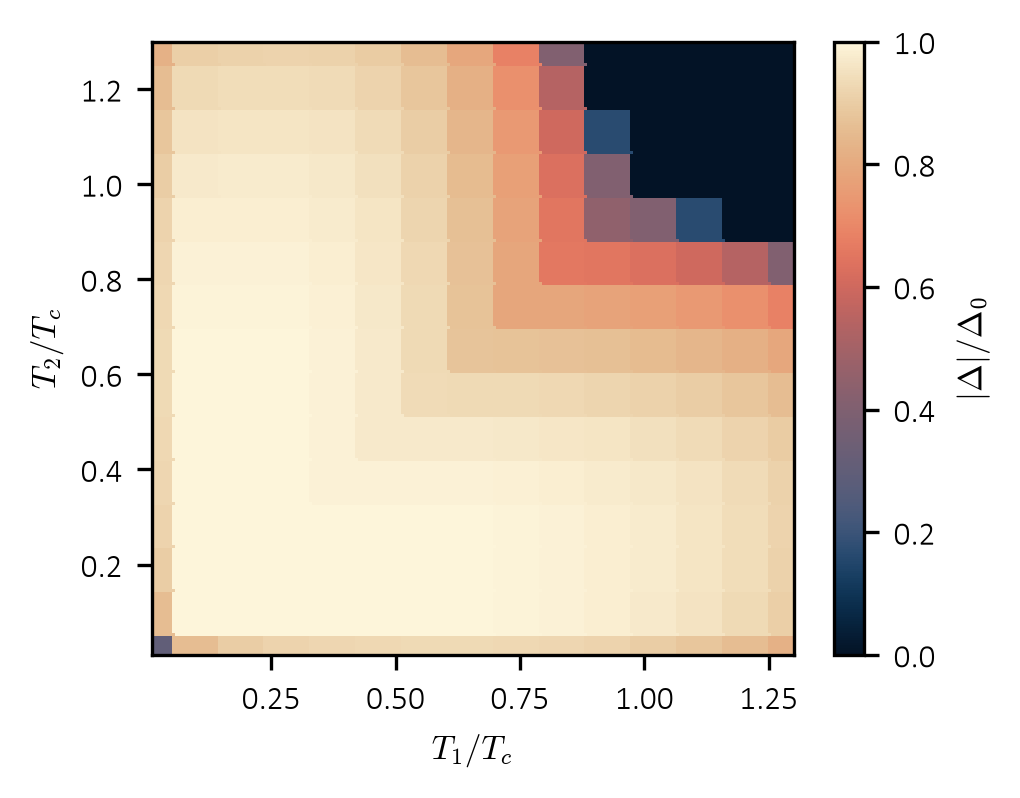

In [ ]:
h = 0.78
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412),
)

zm1 = np.ma.masked_where(~ok, da / d0)
zm2 = da /d0

im = ax.pcolormesh(
    tn,
    tn,
    zm2,
    shading="nearest",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

# if np.any(~ok):
#     iy, ix = np.where(~ok)
#     ax.scatter(
#         tn[ix],
#         tn[iy],
#         color="red",
#         marker="s",
#         s=12,
#         label="nonconverged",
#     )
#     ax.legend()

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$|\Delta|/\Delta_0$",
    rotation=90,
    labelpad=5,
)

ax.set_xlim(tn[0], tn[-1])
ax.set_ylim(tn[0], tn[-1])
ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")

plt.tight_layout()
plt.show()